Decision Tree Accuracy: 1.0000


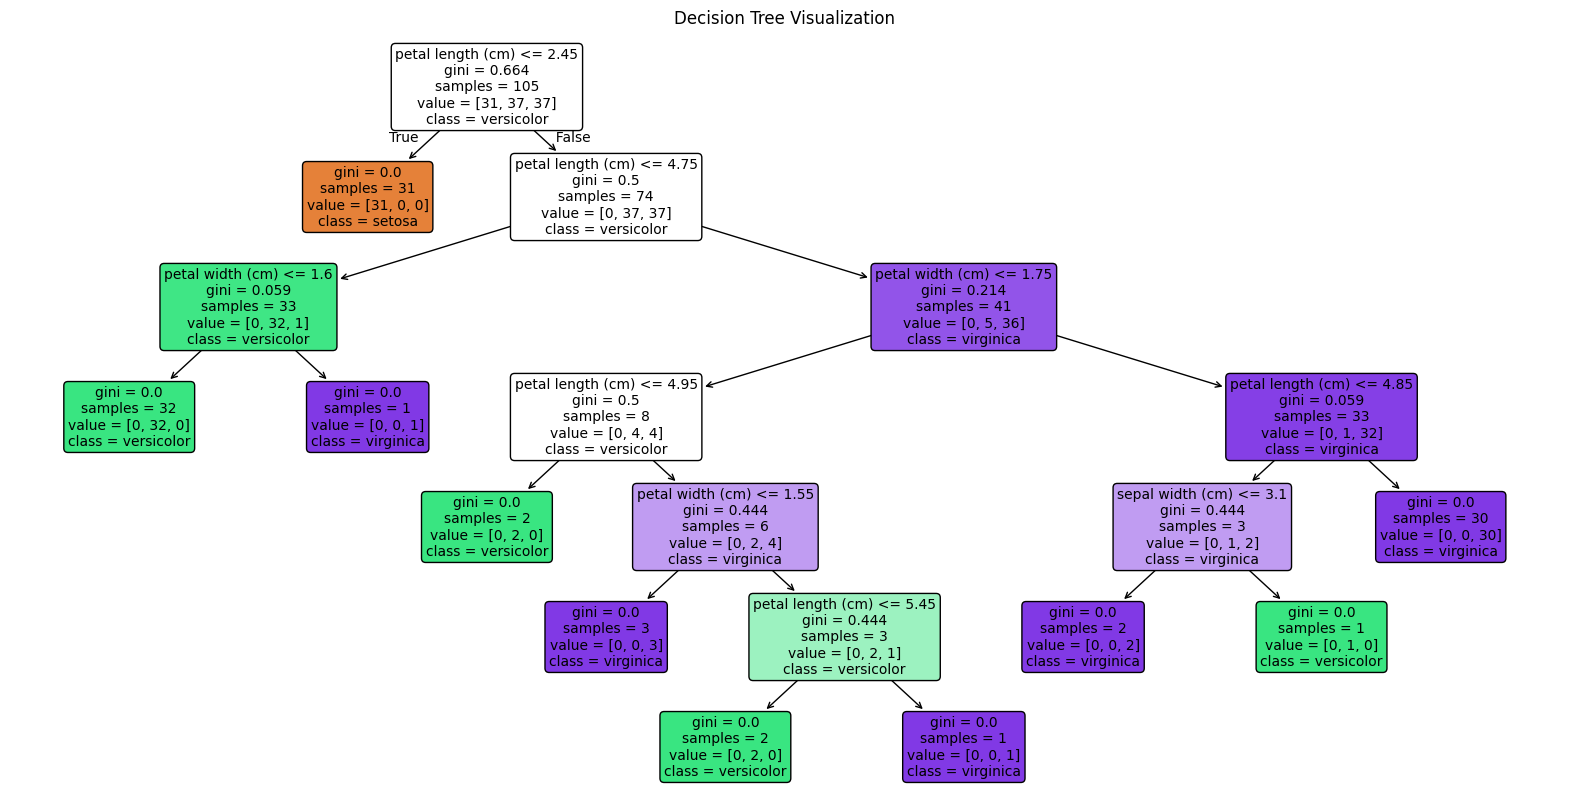

In [ ]:
# PART 1: DECISION TREE CLASSIFICATION

# --- Step 1: Import libraries ---
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# --- Step 2: Load the dataset ---
# We use the classic Iris dataset with 3 flower classes.
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# --- Step 3: Split into training and testing sets (70% train, 30% test) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# --- Step 4: Initialize and train the Decision Tree ---
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

# --- Step 5: Make predictions and evaluate accuracy ---
dt_pred = dt_clf.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

# --- Step 6: Visualize the Decision Tree ---
plt.figure(figsize=(20, 10))
plot_tree(
    dt_clf,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization")
plt.show()

Random Forest Accuracy: 1.0000

Feature Importances:
             Feature  Importance
3   petal width (cm)    0.433982
2  petal length (cm)    0.417308
0  sepal length (cm)    0.104105
1   sepal width (cm)    0.044605


/tmp/ipykernel_1949/2276958960.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")


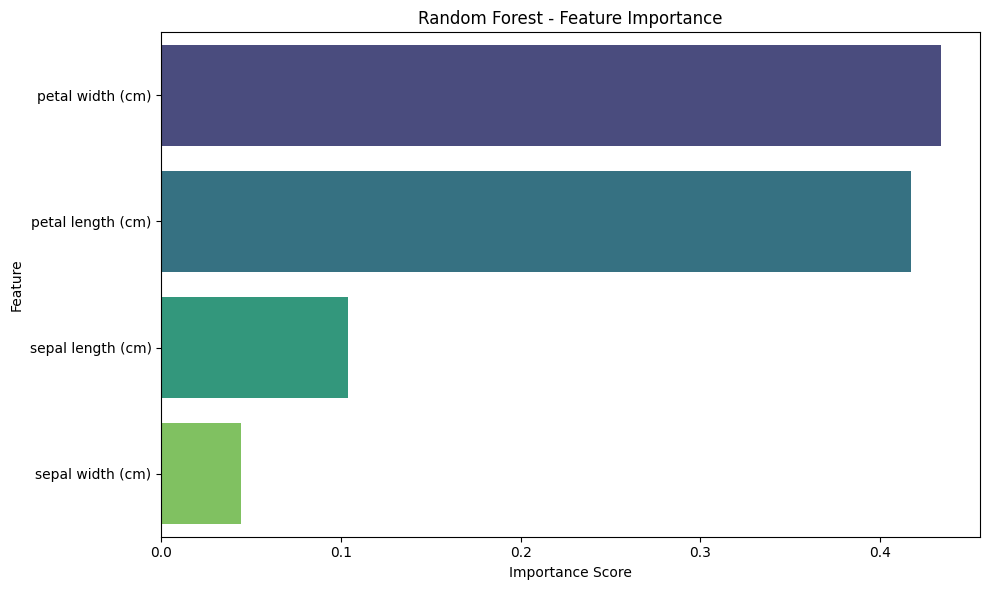

In [ ]:
# PART 2: RANDOM FOREST CLASSIFICATION

# --- Step 1: Import libraries ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 2: Use the same dataset and train-test split from Part 1 ---
# (X_train, X_test, y_train, y_test are reused here)

# --- Step 3: Initialize and train the Random Forest ---
# n_estimators=100 means the forest contains 100 decision trees.
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# --- Step 4: Make predictions and evaluate accuracy ---
rf_pred = rf_clf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

# --- Step 5: Calculate Feature Importance ---
# Create a DataFrame mapping each feature to its importance score.
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_clf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importances:")
print(importance_df)

# --- Step 6: Plot Feature Importance ---
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")
plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
